#### Comparación de modelos realizados

In [5]:
#impprtación de librerías
from pathlib import Path
import sys
import numpy as np
import pandas as pd
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.data.load_split import load_raw_data,split_data
from src.models.train_model import (build_logistic_pipeline,build_random_forest_pipeline,build_xgboost_pipeline)
from src.models.evaluation import evaluate_model_cv, evaluate_on_test

In [4]:
df = load_raw_data()
X_train, X_test, y_train, y_test = split_data(df)

modelos = {

    "Regresión logística ": build_logistic_pipeline(),
    "Random Forest ":build_random_forest_pipeline(),
    "XGBoost ": build_xgboost_pipeline(),
}


In [7]:
filas = []
for nombre, pipe in modelos.items():
    cv = evaluate_model_cv(pipe, X_train, y_train)
    test_metrics, _ ,_= evaluate_on_test(pipe, X_train, y_train, X_test, y_test)
    filas.append({
        "Modelo": nombre,
        "AUC (CV)": cv["roc_auc_mean"],
        "+/- std": cv["roc_auc_std"],
        "AUC (test)": test_metrics["ROC_AUC"],
        "Gini": test_metrics["Gini"],
        "KS": test_metrics["KS"],
    })

tabla = pd.DataFrame(filas).sort_values("AUC (test)",ascending=False)
tabla

,Modelo,AUC (CV),+/- std,AUC (test),Gini,KS
2,XGBoost,0.8563,0.0042,0.8600,0.7200,0.5641
1,Random Forest,0.8440,0.0019,0.8456,0.6913,0.5450
0,Regresión logística,0.8133,0.0040,0.8205,0.6409,0.4990


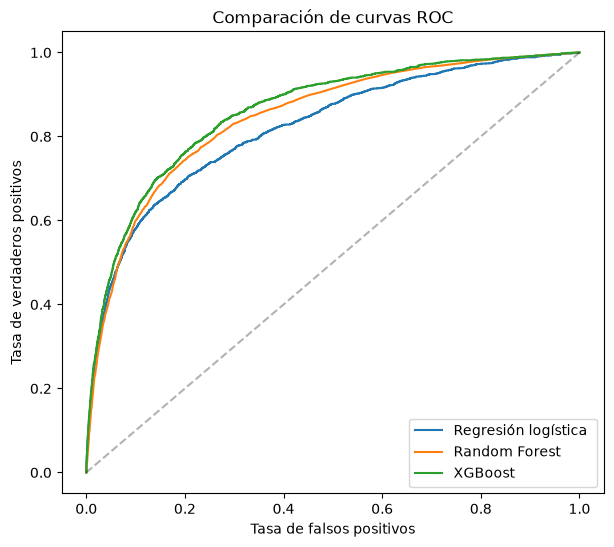

In [9]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))
for nombre, pipe in modelos.items():
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label = nombre)
plt.plot([0,1], [0,1], "k--", alpha=0.3)
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Comparación de curvas ROC")
plt.legend()
plt.show()
